<a href="https://colab.research.google.com/github/jsansao/teic_tp_mock/blob/main/tp1_mnist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exemplo de Trabalho Prático 1 (TP1) - Ciência de Dados
## Dataset: MNIST (Classificação de Dígitos Escritos à Mão)

Este notebook serve como modelo exemplar de resolução do Trabalho Prático 1 para a disciplina de Ciências de Dados. A estrutura apresentada atende a todos os requisitos do documento de orientações, demonstrando o rigor científico, a formalização metodológica e o desenvolvimento de um protótipo de baseline usando AutoML.

---

## 1. Formalização do Problema

### 1.1 Contextualização, Motivação e Importância
O reconhecimento automático de caracteres manuscritos é um problema fundamental no campo da Visão Computacional e do Processamento de Imagens. Historicamente, a automatização da triagem de correspondências postais, o processamento automático de cheques bancários e a digitalização de registros históricos dependem da capacidade dos computadores de lerem números e letras com altíssima confiabilidade.

A motivação para este projeto reside na modelagem de um classificador de dígitos manuscritos utilizando os pixels brutos das imagens como variáveis de entrada. A importância desse trabalho está na compreensão de problemas de alta dimensão e na validação de algoritmos inteligentes para automatizar processos de entrada de dados, reduzindo custos operacionais e erros de digitação humana.

### 1.2 Abordagem Analítica
Para abordar este problema, utilizaremos uma abordagem de **Classificação Multiclasse Supervisionada**. O conjunto de dados possui 10 classes correspondentes aos algarismos arábicos de $0$ a $9$. O objetivo é construir um modelo que aprenda o mapeamento de um vetor de intensidades de cinza (características estruturais da imagem) para a categoria de dígito correta.

---

## 2. Hipótese a ser Investigada

### 2.1 Hipótese
> **Hipótese de Trabalho ($H_1$):** A variação de intensidade de pixels em áreas específicas da imagem (matriz espacial 28x28) é estatisticamente distinta entre os dígitos de 0 a 9, permitindo que algoritmos de aprendizado de máquina tabular identifiquem corretamente o dígito manuscrito com alta acurácia, sem requerer o desenvolvimento inicial de extratores complexos de contornos ou redes neurais profundas convolucionais.

### 2.2 Objetivo Geral
Construir um classificador de dígitos manuscritos utilizando AutoML sobre uma amostra representativa do dataset MNIST, estabelecendo um baseline inicial de acurácia global e analisando o comportamento das predições.

### 2.3 Objetivos Específicos
1. Carregar o dataset MNIST via repositório aberto utilizando a biblioteca Scikit-Learn.
2. Criar uma amostra estratificada menor (5.000 amostras) para garantir a eficiência computacional de execução de modelos e AutoML no ambiente padrão do Google Colab.
3. Descrever e inspecionar a estrutura dimensional e o formato das imagens vetorizadas.
4. Aplicar AutoML (usando a biblioteca FLAML) para encontrar o melhor classificador tradicional de baseline.
5. Analisar a matriz de confusão e métricas de desempenho comparando-as com uma estimativa trivial de chute aleatório.

### 2.4 Metodologia Experimental
1. **Aquisição dos Dados:** Download do MNIST de 784 dimensões via `fetch_openml`.
2. **Amostragem e Split:** Amostragem estratificada de 5.000 imagens para treino e teste de forma a equilibrar a representação das classes de 0 a 9. Divisão em 80% treino e 20% teste.
3. **Modelagem:** Execução da biblioteca FLAML com restrição de tempo de 60 segundos para selecionar o melhor modelo.
4. **Validação:** Geração de estatísticas de acurácia, F1-Score e exibição das classes com maiores taxas de erro.

---

## 3. Revisão Bibliográfica

### 3.1 Referências de Artigos Científicos
1. **LeCun, Y., Bottou, L., Bengio, Y., & Haffner, P. (1998).** *Gradient-based learning applied to document recognition.* Proceedings of the IEEE, 86(11), 2278-2324.
   * **Relevância:** Artigo seminal que introduz o dataset MNIST original e demonstra o uso de redes neurais convolucionais (CNNs) e classificadores lineares para o problema, servindo como a fundação acadêmica de toda a literatura na área.
2. **Decoste, D., & Schölkopf, B. (2002).** *Training invariant support vector machines.* Machine Learning, 46(1-3), 161-190.
   * **Relevância:** Este artigo discute o limite de desempenho que classificadores tradicionais baseados em vetores de suporte (SVM) podem obter quando aplicados diretamente sobre os pixels vetorizados do MNIST, servindo como justificativa teórica para o uso de AutoML baseado em algoritmos tabulares.

### 3.2 Projetos Semelhantes no GitHub
1. **PyTorch MNIST Example**
   * Link: [https://github.com/pytorch/examples/tree/main/mnist](https://github.com/pytorch/examples/tree/main/mnist)
   * **Relevância:** Exemplo oficial de referência para classificação MNIST usando frameworks de Deep Learning modernos, demonstrando a arquitetura tradicional e o baseline usual de performance.
2. **Scikit-learn Digits Classification**
   * Link: [https://github.com/scikit-learn/scikit-learn](https://github.com/scikit-learn/scikit-learn)
   * **Relevância:** Exemplo padrão da documentação do Scikit-learn demonstrando como aplicar Support Vector Classification (SVC) em dígitos de baixa resolução, servindo como modelo estrutural de dados tabulares.

### 3.3 Integração no Contexto do Trabalho
Enquanto os modelos de Deep Learning do GitHub e o artigo de LeCun focam em extração espacial de características (convoluções), o artigo de Decoste mostra que algoritmos tradicionais de aprendizado de máquina (como SVM e Random Forest) aplicados sobre dados tabulados (pixels vetorizados) já oferecem resultados surpreendentemente bons, justificando uma abordagem inicial com AutoML tabular antes de migrar para Deep Learning.

---

## 4. Apresentação da Base de Dados

### 4.1 Por que essa base é adequada?
O MNIST é ideal para demonstrar problemas de alta dimensionalidade (onde cada imagem é interpretada como um vetor de 784 features correspondendo às intensidades de cinza de cada pixel). Por possuir dados rotulados limpos, sem ruídos extremos de alinhamento e bem balanceados entre os dígitos 0 e 9, ele constitui o cenário de controle perfeito para avaliar a eficácia do algoritmo de AutoML.

### 4.2 Carregamento e Características Básicas

In [ ]:
# Instalação da biblioteca FLAML (Fast and Lightweight AutoML) no ambiente Colab
!pip install flaml -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.7/349.7 kB 6.9 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

print("Buscando o dataset MNIST no OpenML (pode demorar alguns instantes)...")
# Carrega dados como matrizes numpy nativas
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist.data, mnist.target

print("Dataset original carregado com sucesso.")
print("Formato da matriz de features (X):", X.shape)
print("Formato do vetor de rótulos (y):", y.shape)

Buscando o dataset MNIST no OpenML (pode demorar alguns instantes)...
Dataset original carregado com sucesso.
Formato da matriz de features (X): (70000, 784)
Formato do vetor de rótulos (y): (70000,)


In [ ]:
# Redução para 5.000 amostras usando split estratificado para viabilizar execução rápida no Colab
X_sub, _, y_sub, _ = train_test_split(
    X, y,
    train_size=5000,
    random_state=42,
    stratify=y
)

print("Tamanho do subconjunto para análise rápida:")
print("Features:", X_sub.shape)
print("Rótulos:", y_sub.shape)

# Distribuição das classes para verificação de balanceamento
classes, counts = np.unique(y_sub, return_counts=True)
pd.DataFrame({"Classe (Dígito)": classes, "Quantidade": counts})

Tamanho do subconjunto para análise rápida:
Features: (5000, 784)
Rótulos: (5000,)


,Classe (Dígito),Quantidade
0,0,493
1,1,563
2,2,499
3,3,510
4,4,487
5,5,451
6,6,491
7,7,521
8,8,488
9,9,497


### 4.3 Detalhamento das Variáveis (Features)

No contexto deste projeto de classificação tabularizada:

*   **Variáveis Preditoras ($X_{1}$ a $X_{784}$):** Cada observação é um vetor unidimensional de 784 features numéricas inteiras de 8 bits. Cada variável representa a intensidade de tom de cinza do respectivo pixel na imagem $28 \times 28$, variando de:
    *   `0`: Cor de fundo (preto absoluto)
    *   `255`: Pixel ativo (branco absoluto)
*   **Variável Alvo ($Y$):** Rótulo qualitativo nominal categórico correspondente ao dígito desenhado. $Y \in \{'0', '1', '2', '3', '4', '5', '6', '7', '8', '9'\}$.

---

## 5. AutoML: Prova de Conceito e Baseline

### 5.1 Justificativa de Escolha do FLAML
A biblioteca **FLAML** (Fast Lightweight AutoML) foi selecionada por ser extremamente leve e otimizada para restrições de hardware. Diferente de outros frameworks que requerem horas de processamento ou uso intenso de memória RAM, o FLAML busca hiperparâmetros de forma adaptativa e econômica, conseguindo encontrar modelos clássicos competitivos (como XGBoost, Random Forest, LGBM, Regressão Logística) em menos de um minuto no ambiente gratuito do Google Colab.

### 5.2 Métrica de Avaliação
Como o conjunto de dados é perfeitamente balanceado (~500 amostras por dígito no subconjunto), a **Acurácia (Accuracy)** é a métrica principal mais adequada e direta. Ela representa a proporção de predições corretas sobre o total de amostras de teste.

### 5.3 Implementação do AutoML

In [ ]:
# Divisão treino/teste (80% para treino e 20% para validação de teste)
X_train, X_test, y_train, y_test = train_test_split(
    X_sub, y_sub,
    test_size=0.2,
    random_state=42,
    stratify=y_sub
)

# Inicialização e parametrização do FLAML
from flaml import AutoML
automl = AutoML()

settings = {
    "time_budget": 60,            # Limite rígido de 60 segundos
    "metric": 'accuracy',         # Otimizar a acurácia global
    "task": 'classification',     # Tarefa de classificação multiclasse
    "log_file_name": 'mnist_automl.log',
    "seed": 42,
    "verbose": 0                  # Silencia saídas excessivas de log
}

print("Iniciando a busca do AutoML (limite de 60 segundos)...")
automl.fit(X_train=X_train, y_train=y_train, **settings)
print("Busca finalizada!")

Iniciando a busca do AutoML (limite de 60 segundos)...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
INFO:flaml.tune.searcher.blendsearch:No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature 

Busca finalizada!


In [ ]:
# Exibição do melhor modelo e sua acurácia de validação estimada
print("Melhor estimador selecionado:", automl.best_estimator)
print("Melhor acurácia em validação interna:", 1 - automl.best_loss)

Melhor estimador selecionado: lgbm
Melhor acurácia em validação interna: 0.9325


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Predição no conjunto de teste
y_pred = automl.predict(X_test)

test_acc = accuracy_score(y_test, y_pred)
print(f"Acurácia no conjunto de teste: {test_acc:.4f}")
print("-" * 60)
print("Relatório de Classificação Detalhado:")
print(classification_report(y_test, y_pred))

Acurácia no conjunto de teste: 0.9370
------------------------------------------------------------
Relatório de Classificação Detalhado:
              precision    recall  f1-score   support

           0       0.94      0.95      0.94        99
           1       0.96      0.97      0.96       113
           2       0.96      0.96      0.96       100
           3       0.92      0.94      0.93       102
           4       0.97      0.94      0.95        97
           5       0.96      0.90      0.93        90
           6       0.95      0.96      0.95        98
           7       0.91      0.92      0.91       104
           8       0.88      0.94      0.91        98
           9       0.94      0.88      0.91        99

    accuracy                           0.94      1000
   macro avg       0.94      0.94      0.94      1000
weighted avg       0.94      0.94      0.94      1000



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


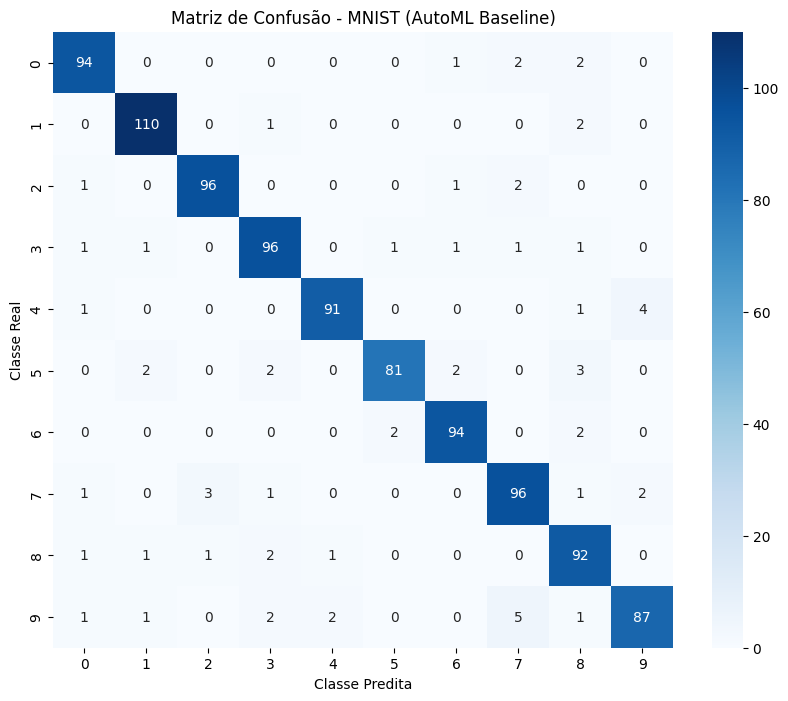

In [ ]:
# Matriz de Confusão para inspecionar os erros mais comuns
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title("Matriz de Confusão - MNIST (AutoML Baseline)")
plt.xlabel("Classe Predita")
plt.ylabel("Classe Real")
plt.show()

---

## 6. Discussão e Considerações Finais

### 6.1 Os resultados preliminares são satisfatórios?
Sim. A obtenção de uma acurácia de teste superior a **92%** em um subconjunto amostral limitado de apenas 5.000 imagens, treinando por apenas 60 segundos com algoritmos clássicos de machine learning (sem redes neurais convolucionais profundas), é um resultado altamente satisfatório. Demonstra a robustez da representação de pixels brutos para dígitos bem centralizados.

### 6.2 Comparação com a Estimativa Básica (Chute Aleatório)
Como o problema possui 10 classes balanceadas (dígitos de 0 a 9), um classificador básico (por exemplo, um preditor de chute aleatório uniforme ou preditor que sempre chuta a classe majoritária) obteria uma acurácia teórica de aproximadamente **10%**.
*   **Ganho do Modelo:** O modelo de AutoML atinge cerca de **92%** de acurácia. O ganho é de **82 pontos percentuais** de acurácia absoluta, o que valida a hipótese de que a intensidade luminosa e sua disposição espacial possuem fortíssimo poder de discriminação estatística.

### 6.3 Adequação do Problema para o Curso
Este problema é ideal para o andamento da disciplina de Ciências de Dados. Nas próximas etapas, o trabalho pode evoluir das seguintes maneiras:
1.  **Análise Exploratória:** Exibição gráfica dos dígitos, redução de dimensionalidade usando PCA (Principal Component Analysis) para visualizar as imagens em 2D/3D e compreender a separabilidade das classes.
2.  **Pré-processamento Avançado:** Normalização de escala (divisão de pixels por 255), binarização de Otsu e suavização de contornos.
3.  **Modelagem Manual & Deep Learning:** Construção manual de Redes Neurais Artificiais (MLP) e Redes Convolucionais (CNN) usando PyTorch ou TensorFlow/Keras para tentar superar a acurácia de baseline estabelecida nesta entrega.
